# 02 - Nearest Neighbours

## Introduction

Nearest Neighbours is a **distance-based supervised learning method**.

The basic idea is simple:

> Similar data points are usually located close to each other.

Instead of learning a complicated mathematical model, K-Nearest Neighbours (KNN) looks at the **nearest data points** and uses them to make a prediction.

KNN can be used for:

* **Classification** → predict a category
* **Regression** → predict a numerical value

In this notebook, we will understand KNN from the basics and implement it using Python and Scikit-Learn.


In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_squared_error,
    r2_score
)

# What is K-Nearest Neighbours?

K-Nearest Neighbours is a supervised learning algorithm that makes predictions based on the **K closest training examples**.

Suppose we have a new data point.

KNN:

1. Calculates the distance between the new point and training points.
2. Finds the `K` closest points.
3. Looks at their target values.
4. Makes a prediction based on those neighbours.

For classification, KNN usually uses **majority voting**.

For regression, KNN usually uses the **average value** of the neighbours.

### Example

Suppose we want to classify a new fruit.

The three nearest fruits are:

* Apple
* Apple
* Orange

If:

```text
K = 3
```

then the majority class is:

```text
Apple
```

Therefore, KNN predicts:

```text
Apple
```


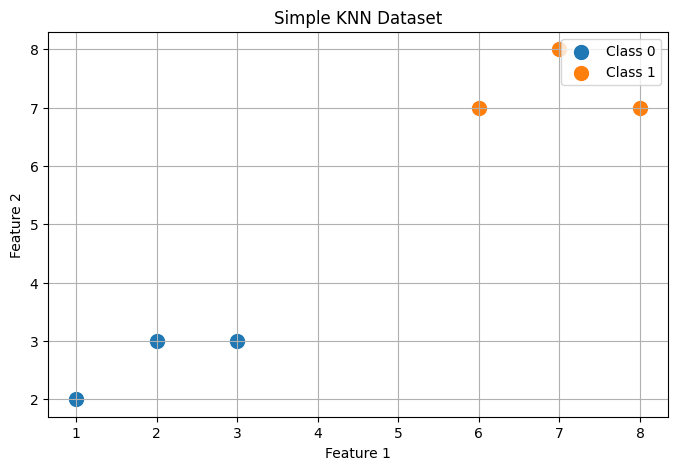

In [2]:
# Create a simple dataset

X = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 7],
    [7, 8],
    [8, 7]
])

y = np.array([
    0,
    0,
    0,
    1,
    1,
    1
])

# Plot the data

plt.figure(figsize=(8, 5))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0",
    s=100
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1",
    s=100
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Simple KNN Dataset")
plt.legend()
plt.grid()
plt.show()

# Mathematical Foundation

KNN depends heavily on **distance**.

The most commonly used distance is **Euclidean Distance**.

For two points:

$$
A=(x_1,y_1)
$$

and

$$
B=(x_2,y_2)
$$

the Euclidean distance is:

$$
d(A,B)=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}
$$

For `n` dimensions:

$$
d(A,B)=
\sqrt{
\sum_{i=1}^{n}(x_i-y_i)^2
}
$$

### Example

Consider:

$$
A=(2,3)
$$

$$
B=(5,7)
$$

Then:

$$
d(A,B)
=
\sqrt{(5-2)^2+(7-3)^2}
$$

$$
=
\sqrt{3^2+4^2}
$$

$$
=
\sqrt{25}
$$

$$
=5
$$

So the distance between the two points is **5**.


In [3]:
# Define two points

A = np.array([2, 3])
B = np.array([5, 7])

# Calculate Euclidean distance

distance = np.sqrt(np.sum((A - B) ** 2))

print("Euclidean Distance:", distance)

Euclidean Distance: 5.0


# Manhattan Distance

Another distance metric is **Manhattan Distance**.

It calculates distance by adding the absolute differences between coordinates.

$$
d(A,B)=
\sum_{i=1}^{n}|x_i-y_i|
$$

For:

$$
A=(2,3)
$$

and:

$$
B=(5,7)
$$

we get:

$$
d=|5-2|+|7-3|
$$

$$
=3+4
$$

$$
=7
$$

Therefore:

$$
\boxed{d=7}
$$

Manhattan distance is also called **L1 distance**.


In [4]:
# Calculate Manhattan distance

manhattan_distance = np.sum(np.abs(A - B))

print("Manhattan Distance:", manhattan_distance)

Manhattan Distance: 7


## Euclidean vs. Manhattan Distance

| Distance Metric | Formula | Common Name |
| :--- | :--- | :--- |
| **Euclidean** | $\sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$ | $L_2$ distance |
| **Manhattan** | $\sum_{i=1}^{n}\|x_i - y_i\|$ | $L_1$ distance |

KNN allows us to choose different distance metrics depending on the problem.

# Understanding K

`K` represents the number of nearest neighbours considered for making a prediction.

For example:

```text
K = 1
```

uses only the closest data point.

```text
K = 3
```

uses the three closest data points.

```text
K = 5
```

uses the five closest data points.

### Small K

A small value such as:

```text
K = 1
```

can make the model sensitive to individual data points and noise.

This can lead to **overfitting**.

### Large K

A very large value of `K` considers many data points.

This produces smoother predictions but can make the model too general.

This can lead to **underfitting**.

Therefore, choosing a suitable value of `K` is important.


# KNN Classification

For classification, KNN uses the classes of the nearest neighbours.

Suppose:

```text
K = 5
```

and the nearest neighbours are:

```text
Class A
Class A
Class B
Class A
Class B
```

The votes are:

```text
Class A → 3
Class B → 2
```

Therefore:

$$
\boxed{\text{Prediction = Class A}}
$$

This is called **majority voting**.


## Implement KNN Classification

In [5]:
# Create the KNN classifier

knn = KNeighborsClassifier(
    n_neighbors=3
)

# Train the model

knn.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Make a Prediction

In [6]:
# New data point

new_point = np.array([[4, 4]])

# Predict the class

prediction = knn.predict(new_point)

print("Predicted Class:", prediction[0])

Predicted Class: 0


## Get Nearest Neighbours

In [7]:
# Find the 3 nearest neighbours

distances, indices = knn.kneighbors(new_point)

print("Distances:")
print(distances)

print("\nIndices of Neighbours:")
print(indices)

Distances:
[[1.41421356 2.23606798 3.60555128]]

Indices of Neighbours:
[[2 1 0]]


# Feature Scaling

KNN is a distance-based algorithm.

Therefore, the scale of features can strongly affect the result.

Suppose we have:

```text
Age       → 18 to 60
Salary    → 20,000 to 2,00,000
```

Salary has much larger numerical values than age.

Without scaling, the salary feature can dominate the distance calculation.

Therefore, we commonly use **Standardization**.

### Standardization

$$
z=\frac{x-\mu}{\sigma}
$$

where:

* \(x\) = original value
* \(\mu\) = mean
* \(\sigma\) = standard deviation

After standardization, features are placed on a comparable scale.

For KNN, feature scaling is usually an important preprocessing step.


## StandardScaler Example

In [8]:
# Create a scaler

scaler = StandardScaler()

# Fit and transform the data

X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-1.33082093 -1.26025208]
 [-0.95058638 -0.84016805]
 [-0.57035183 -0.84016805]
 [ 0.57035183  0.84016805]
 [ 0.95058638  1.26025208]
 [ 1.33082093  0.84016805]]


## Train KNN with Scaled Data

In [9]:
# Create KNN model

knn_scaled = KNeighborsClassifier(
    n_neighbors=3
)

# Train using scaled data

knn_scaled.fit(X_scaled, y)

# Scale the new point

new_point_scaled = scaler.transform(new_point)

# Make prediction

prediction = knn_scaled.predict(new_point_scaled)

print("Predicted Class:", prediction[0])

Predicted Class: 0


## KNN on a Real Dataset

In [10]:
from sklearn.datasets import load_iris

# Load Iris dataset

iris = load_iris()

X = iris.data
y = iris.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


In [11]:
# Display feature names

print("Feature Names:")
print(iris.feature_names)

print("\nTarget Names:")
print(iris.target_names)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names:
['setosa' 'versicolor' 'virginica']


## Train-Test Split

In [12]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## Scale the Data

In [13]:
# Create scaler

scaler = StandardScaler()

# Fit scaler only on training data

X_train_scaled = scaler.fit_transform(X_train)

# Transform test data

X_test_scaled = scaler.transform(X_test)

## Train KNN Model

In [14]:
# Create KNN model

knn = KNeighborsClassifier(
    n_neighbors=5
)

# Train the model

knn.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Make Predictions

In [15]:
# Predict test data

y_pred = knn.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]


## Evaluate the Model

In [16]:
# Calculate accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [17]:
# Confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


In [18]:
# Classification report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



# Choosing the Best K

There is no single value of `K` that is always best.

We can test multiple values of `K` and compare their performance.

For example:

```text
K = 1
K = 2
K = 3
...
K = 20
```

We can calculate the accuracy for each value and choose an appropriate `K`.


In [19]:
# Test different values of K

k_values = range(1, 21)

accuracies = []

for k in k_values:
    
    model = KNeighborsClassifier(
        n_neighbors=k
    )
    
    model.fit(
        X_train_scaled,
        y_train
    )
    
    predictions = model.predict(
        X_test_scaled
    )
    
    accuracy = accuracy_score(
        y_test,
        predictions
    )
    
    accuracies.append(accuracy)

## Plot Accuracy vs K

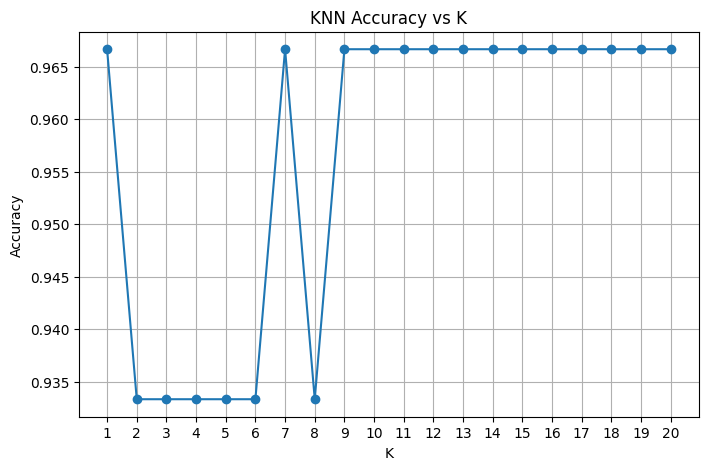

In [20]:
# Plot accuracy for different K values

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.xticks(list(k_values))
plt.grid()

plt.show()

## Find Best K

In [21]:
# Find the K with the highest accuracy

best_index = np.argmax(accuracies)

best_k = list(k_values)[best_index]
best_accuracy = accuracies[best_index]

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 1
Best Accuracy: 0.9666666666666667


# KNN Regression

In KNN regression, the prediction is usually calculated using the average target value of the nearest neighbours.

Suppose:

```text
K = 3
```

and the nearest neighbours have target values:

```text
10
20
30
```

Then:

$$
Prediction =
\frac{10+20+30}{3}
$$

$$
=20
$$

Therefore:

$$
\boxed{Prediction=20}
$$

So:

* **KNN Classification** → majority vote
* **KNN Regression** → average of neighbours


## Simple KNN Regression Example

In [22]:
# Create regression dataset

X_reg = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
    [6]
])

y_reg = np.array([
    10,
    20,
    30,
    40,
    50,
    60
])

# Create KNN regression model

knn_reg = KNeighborsRegressor(
    n_neighbors=3
)

# Train model

knn_reg.fit(
    X_reg,
    y_reg
)

# Make prediction

prediction = knn_reg.predict(
    [[3.5]]
)

print("Predicted value:", prediction[0])

Predicted value: 30.0


# Advantages and Disadvantages of KNN

## Advantages

* Simple and easy to understand
* Easy to implement
* Can be used for classification and regression
* No complex training process
* Can model non-linear decision boundaries

## Disadvantages

* Prediction can be computationally expensive for large datasets
* Sensitive to feature scaling
* Sensitive to irrelevant features
* Choosing the right `K` is important
* Performance can decrease in high-dimensional datasets


# Summary

In this notebook, we learned:

* What Nearest Neighbours means
* How KNN works
* Euclidean distance
* Manhattan distance
* The importance of `K`
* KNN classification
* KNN regression
* Feature scaling
* Training KNN using Scikit-Learn
* Model evaluation
* Selecting a suitable value of `K`

The core idea of KNN is:

$$
\boxed{\text{Find nearby points and use them to make a prediction}}
$$

For classification:

$$
\boxed{\text{Majority Vote}}
$$

For regression:

$$
\boxed{\text{Average of Neighbours}}
$$
